# Caso SQL — Servicio de libros: propuesta de valor para un nuevo producto

**Contexto**: La pandemia cambió los hábitos de ocio y desplazó tiempo libre hacia la lectura en casa. Eso atrajo a startups que se apresuraron a desarrollar aplicaciones para amantes de los libros.

Se dispone de la base de datos de uno de los servicios que compiten en ese mercado, con información de libros, editoriales, autores, calificaciones y reseñas. El encargo es **estudiar su contenido para fundamentar la propuesta de valor de un nuevo producto**.

## Objetivos del estudio

Cinco preguntas concretas guían el análisis, y cada una se resuelve con una consulta SQL:

1. ¿Cuántos libros se publicaron después del 1 de enero de 2000?
2. ¿Cuántas reseñas y qué calificación promedio tiene cada libro?
3. ¿Qué editorial ha publicado el mayor número de libros de más de 50 páginas?
4. ¿Qué autor tiene la calificación promedio más alta, considerando solo libros con al menos 50 calificaciones?
5. ¿Cuántas reseñas de texto escriben, en promedio, los usuarios que calificaron más de 50 libros?

> **Restricción técnica:** todos los resultados se obtienen **con SQL**. `pandas` se utiliza únicamente para ejecutar las consultas y mostrar sus resultados, nunca para agregar o filtrar datos que la base pueda resolver.

---

**Contenido**

1. Conexión a la base de datos
2. Exploración de las tablas
3. Consulta 1 — Libros publicados después del año 2000
4. Consulta 2 — Reseñas y calificación promedio por libro
5. Consulta 3 — Editorial con más libros de más de 50 páginas
6. Consulta 4 — Autor mejor valorado
7. Consulta 5 — Actividad de los usuarios más comprometidos
8. Conclusiones y propuesta de valor

---
# 1. Conexión a la base de datos

La conexión se realiza sobre PostgreSQL con SSL. El certificado `CA.pem` debe encontrarse en esta misma carpeta, junto al notebook.

In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 60)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
AZUL = '#4C72B0'

print('Certificado CA.pem presente:', os.path.exists('CA.pem'))

# Credenciales de la base de datos compartida del curso — se leen desde
# variables de entorno (.env, no versionado). Ver .env.example para las claves esperadas.
db_config = {
    'user': os.environ['DB_USER'],
    'pwd': os.environ['DB_PWD'],
    'host': os.environ['DB_HOST'],
    'port': os.environ['DB_PORT'],
    'db': os.environ['DB_NAME'],
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'], db_config['pwd'], db_config['host'],
    db_config['port'], db_config['db'])

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})


def consultar(sql):
    """Ejecuta una consulta SQL y devuelve el resultado como DataFrame."""
    return pd.read_sql(sql, con=engine)


print('Conexión establecida:', consultar('SELECT 1 AS ok')['ok'][0] == 1)

---
# 2. Exploración de las tablas

El esquema consta de cinco tablas: `books` (con claves foráneas a `authors` y `publishers`), y `ratings` y `reviews`, ambas referidas a `books` e identificando al usuario por `username`.

In [2]:
TABLAS = ['books', 'authors', 'publishers', 'ratings', 'reviews']

volumen = consultar('''
SELECT 'books'      AS tabla, COUNT(*) AS filas FROM books
UNION ALL SELECT 'authors',    COUNT(*) FROM authors
UNION ALL SELECT 'publishers', COUNT(*) FROM publishers
UNION ALL SELECT 'ratings',    COUNT(*) FROM ratings
UNION ALL SELECT 'reviews',    COUNT(*) FROM reviews
ORDER BY filas DESC
''')
volumen

,tabla,filas
0,ratings,6456
1,reviews,2793
2,books,1000
3,authors,636
4,publishers,340


In [3]:
for tabla in TABLAS:
    print(f'--- {tabla} ---')
    display(consultar(f'SELECT * FROM {tabla} LIMIT 5'))

--- books ---


,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope #1),322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before Columbus,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268


--- authors ---


,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd


--- publishers ---


,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company


--- ratings ---


,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2


--- reviews ---


,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. Over provi...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Among admit i...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but person spo...
3,4,3,johnsonamanda,Finally month interesting blue could nature cultural bit...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List dinner an...


In [4]:
contexto = consultar('''
SELECT MIN(publication_date)  AS primera_publicacion,
       MAX(publication_date)  AS ultima_publicacion,
       MIN(num_pages)         AS min_paginas,
       MAX(num_pages)         AS max_paginas,
       ROUND(AVG(num_pages))  AS media_paginas
FROM books
''')
display(contexto)

cobertura = consultar('''
SELECT COUNT(DISTINCT r.book_id)                     AS libros_con_calificacion,
       COUNT(DISTINCT rv.book_id)                    AS libros_con_resena,
       (SELECT COUNT(*) FROM books)                  AS libros_totales,
       (SELECT COUNT(DISTINCT username) FROM ratings) AS usuarios_calificadores,
       (SELECT ROUND(AVG(rating), 2) FROM ratings)   AS rating_medio_global
FROM ratings r
FULL JOIN reviews rv ON rv.book_id = r.book_id
''')
cobertura

,primera_publicacion,ultima_publicacion,min_paginas,max_paginas,media_paginas
0,1952-12-01,2020-03-31,14,2690,389.0


,libros_con_calificacion,libros_con_resena,libros_totales,usuarios_calificadores,rating_medio_global
0,1000,994,1000,160,3.93


**Observación** El catálogo es pequeño y prácticamente todos los libros tienen calificaciones, aunque no todos tienen reseñas escritas. La calificación media global se sitúa en torno a 4 sobre 5, un sesgo positivo habitual en plataformas de valoración voluntaria: quien se molesta en puntuar suele hacerlo porque el libro le gustó.

## 2.1 Verificación de la calidad de los datos

Antes de responder a las cinco preguntas conviene comprobar que la base no arrastra defectos que invaliden los resultados: valores ausentes en las claves, referencias rotas entre tablas y calificaciones fuera de escala.

In [5]:
integridad = consultar('''
SELECT
    (SELECT COUNT(*) FROM books WHERE author_id IS NULL)        AS libros_sin_autor,
    (SELECT COUNT(*) FROM books WHERE publisher_id IS NULL)     AS libros_sin_editorial,
    (SELECT COUNT(*) FROM books WHERE title IS NULL)            AS libros_sin_titulo,
    (SELECT COUNT(*) FROM books b
     LEFT JOIN authors a ON a.author_id = b.author_id
     WHERE a.author_id IS NULL)                                 AS autor_inexistente,
    (SELECT COUNT(*) FROM ratings r
     LEFT JOIN books b ON b.book_id = r.book_id
     WHERE b.book_id IS NULL)                                   AS calificaciones_huerfanas,
    (SELECT COUNT(*) FROM reviews rv
     LEFT JOIN books b ON b.book_id = rv.book_id
     WHERE b.book_id IS NULL)                                   AS resenas_huerfanas
''')
display(integridad.T.rename(columns={0: 'registros'}))

rango_rating = consultar('''
SELECT MIN(rating) AS minimo, MAX(rating) AS maximo,
       COUNT(*) FILTER (WHERE rating < 1 OR rating > 5) AS fuera_de_escala
FROM ratings
''')
display(rango_rating)

print('Reseñas escritas por usuarios que no han calificado ese mismo libro:')
display(consultar('''
SELECT COUNT(*) AS resenas_sin_calificacion
FROM reviews rv
LEFT JOIN ratings rt ON rt.book_id = rv.book_id AND rt.username = rv.username
WHERE rt.rating_id IS NULL
'''))

,registros
libros_sin_autor,0
libros_sin_editorial,0
libros_sin_titulo,0
autor_inexistente,0
calificaciones_huerfanas,0
resenas_huerfanas,0


,minimo,maximo,fuera_de_escala
0,1,5,0


Reseñas escritas por usuarios que no han calificado ese mismo libro:


,resenas_sin_calificacion
0,0


**Observación** La base está limpia: no hay libros sin autor, editorial ni título, ninguna calificación o reseña apunta a un libro inexistente, y todas las puntuaciones caen dentro de la escala de 1 a 5. No hacen falta decisiones de limpieza antes de responder a las preguntas.

La última comprobación aporta además un dato de comportamiento: **toda reseña escrita lleva asociada una calificación del mismo usuario sobre el mismo libro**. Escribir una reseña implica puntuar, pero no al revés — hay muchas más calificaciones que reseñas. Esto es coherente porque una reseña es una tareas mas costosa y no todos los usuarios quieren hacerlo, creando asi la asimetria observada.

Conviene subrayar que esto **no** permite unir `ratings` y `reviews` directamente en una sola consulta: un libro con 60 calificaciones y 5 reseñas produciría 300 filas al cruzarlas. La consulta 2 agrega cada tabla por separado precisamente para evitarlo.

---
# 3. Consulta 1 — Libros publicados después del 1 de enero de 2000

Sirve para dimensionar cuán actual es el catálogo, lo que condiciona a qué tipo de lector puede dirigirse el producto.

In [6]:
consulta_1 = '''
SELECT COUNT(*) AS libros_desde_2000
FROM books
WHERE publication_date > '2000-01-01'
'''
resultado_1 = consultar(consulta_1)
display(resultado_1)

total_libros = consultar('SELECT COUNT(*) AS n FROM books')['n'][0]
n1 = resultado_1['libros_desde_2000'][0]
print(f'{n1} de {total_libros} libros ({n1 / total_libros:.1%}) se publicaron después del 1 de enero de 2000.')

,libros_desde_2000
0,819


819 de 1000 libros (81.9%) se publicaron después del 1 de enero de 2000.


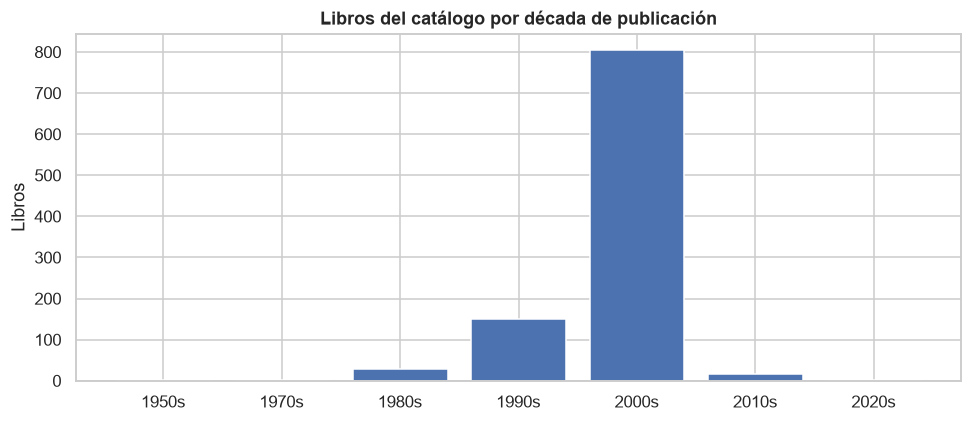

,decada,libros
0,1950s,1
1,1970s,1
2,1980s,28
3,1990s,149
4,2000s,804
5,2010s,16
6,2020s,1


In [7]:
por_decada = consultar('''
SELECT CONCAT(FLOOR(EXTRACT(YEAR FROM publication_date) / 10) * 10, 's') AS decada,
       COUNT(*) AS libros
FROM books
GROUP BY 1
ORDER BY 1
''')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(por_decada['decada'], por_decada['libros'], color=AZUL)
ax.set_title('Libros del catálogo por década de publicación')
ax.set_ylabel('Libros')
plt.tight_layout()
plt.show()

por_decada

**Conclusión 1.** Más de cuatro de cada cinco libros del catálogo son posteriores al año 2000, y la concentración se acentúa en la década de 2000. El servicio dispone de un **catálogo contemporáneo**, no de un fondo histórico. Eso es una ventaja para captar lectores generalistas y de novedades, pero limita la propuesta si se quisiera competir en literatura clásica.

---
# 4. Consulta 2 — Reseñas y calificación promedio por libro

Es la tabla base de cualquier funcionalidad de descubrimiento: qué se comenta y cómo se valora.

**Detalle técnico:** unir `reviews` y `ratings` directamente multiplicaría las filas (cada reseña se emparejaría con cada calificación del mismo libro, inflando los conteos). Se agrega cada tabla **por separado** en subconsultas y después se combinan, que es la forma correcta de evitar ese producto cartesiano.

In [8]:
consulta_2 = '''
SELECT b.book_id,
       b.title,
       COALESCE(rv.resenas, 0)  AS resenas,
       rt.calificaciones,
       ROUND(rt.rating_medio, 2) AS rating_medio
FROM books b
LEFT JOIN (SELECT book_id, COUNT(review_id) AS resenas
           FROM reviews GROUP BY book_id) rv ON rv.book_id = b.book_id
LEFT JOIN (SELECT book_id, COUNT(rating_id) AS calificaciones,
                  AVG(rating) AS rating_medio
           FROM ratings GROUP BY book_id) rt ON rt.book_id = b.book_id
ORDER BY resenas DESC, rating_medio DESC NULLS LAST
'''
resultado_2 = consultar(consulta_2)

print(f'Filas devueltas: {len(resultado_2):,} (una por libro del catálogo)\n')
print('Los 10 libros más reseñados:')
display(resultado_2.head(10))

Filas devueltas: 1,000 (una por libro del catálogo)

Los 10 libros más reseñados:


,book_id,title,resenas,calificaciones,rating_medio
0,948,Twilight (Twilight #1),7,160,3.66
1,302,Harry Potter and the Prisoner of Azkaban (Harry Potter #3),6,82,4.41
2,299,Harry Potter and the Chamber of Secrets (Harry Potter #2),6,80,4.29
3,656,The Book Thief,6,53,4.26
4,734,The Glass Castle,6,29,4.21
5,497,Outlander (Outlander #1),6,24,4.13
6,750,The Hobbit or There and Back Again,6,88,4.13
7,695,The Curious Incident of the Dog in the Night-Time,6,37,4.08
8,779,The Lightning Thief (Percy Jackson and the Olympians #1),6,62,4.08
9,963,Water for Elephants,6,44,3.98


Libros sin ninguna reseña de texto : 6
Libros sin ninguna calificación    : 0

Distribución del número de reseñas por libro:
count    1000.00
mean        2.79
std         1.07
min         0.00
25%         2.00
50%         3.00
75%         3.00
95%         5.00
max         7.00


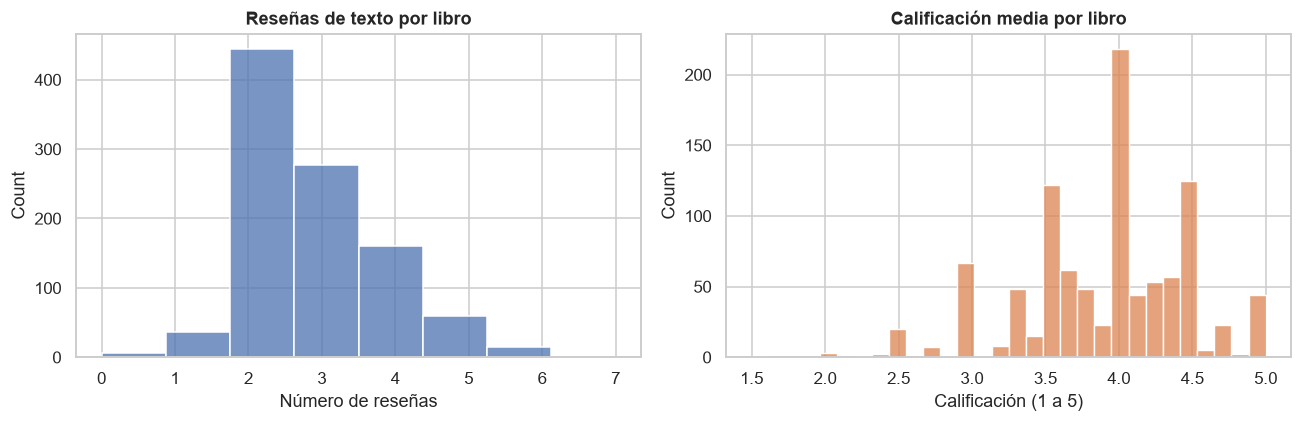

In [9]:
print('Libros sin ninguna reseña de texto :',
      int((resultado_2['resenas'] == 0).sum()))
print('Libros sin ninguna calificación    :',
      int(resultado_2['calificaciones'].isna().sum()))
print()
print('Distribución del número de reseñas por libro:')
print(resultado_2['resenas'].describe(percentiles=[.25, .5, .75, .95]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(resultado_2['resenas'], bins=resultado_2['resenas'].max() + 1, color=AZUL, ax=axes[0])
axes[0].set_title('Reseñas de texto por libro')
axes[0].set_xlabel('Número de reseñas')

sns.histplot(resultado_2['rating_medio'].dropna(), bins=30, color='#DD8452', ax=axes[1])
axes[1].set_title('Calificación media por libro')
axes[1].set_xlabel('Calificación (1 a 5)')

plt.tight_layout()
plt.show()

**Conclusión 2.** La actividad de reseña es **escasa y muy desigual**: la mayoría de los libros acumula unas pocas reseñas y ninguno supera la decena, mientras que las calificaciones se concentran en la parte alta de la escala.

Esto tiene dos implicaciones para el producto. Primera, **la calificación media aislada no sirve para recomendar**: hay pocas valoraciones por libro y en su mayoria son altas, siendo dificil discriminar. Segunda, la reseña escrita es el activo escaso y, por tanto, es más valioso: un producto que consiga aumentar el volumen de reseñas construye una ventaja difícil de replicar.

---
# 5. Consulta 3 — Editorial con más libros de más de 50 páginas

El filtro de páginas excluye folletos y publicaciones menores, de modo que el recuento refleje catálogo editorial real.

In [10]:
consulta_3 = '''
SELECT p.publisher,
       COUNT(b.book_id) AS libros
FROM books b
JOIN publishers p ON p.publisher_id = b.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher
ORDER BY libros DESC
LIMIT 10
'''
resultado_3 = consultar(consulta_3)
display(resultado_3)

excluidos = consultar('SELECT COUNT(*) AS n FROM books WHERE num_pages <= 50')['n'][0]
print(f'Libros excluidos por tener 50 páginas o menos: {excluidos}')
print(f'La editorial líder es "{resultado_3["publisher"][0]}" con {resultado_3["libros"][0]} libros.')

,publisher,libros
0,Penguin Books,42
1,Vintage,31
2,Grand Central Publishing,25
3,Penguin Classics,24
4,Ballantine Books,19
5,Bantam,19
6,Berkley,17
7,St. Martin's Press,14
8,Berkley Books,14
9,William Morrow Paperbacks,13


Libros excluidos por tener 50 páginas o menos: 8
La editorial líder es "Penguin Books" con 42 libros.


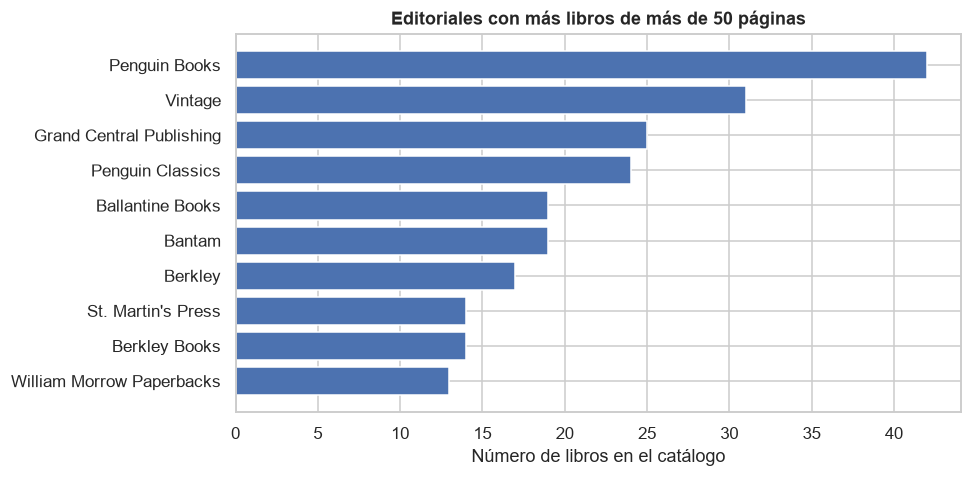

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
top = resultado_3.iloc[::-1]
ax.barh(top['publisher'], top['libros'], color=AZUL)
ax.set_title('Editoriales con más libros de más de 50 páginas')
ax.set_xlabel('Número de libros en el catálogo')
plt.tight_layout()
plt.show()

**Conclusión 3.** **Penguin Books** encabeza el catálogo, seguida de Vintage y Grand Central Publishing. El filtro de 50 páginas apenas descarta títulos, lo que confirma que el catálogo está compuesto por obras completas y no por material menor.

**Implicación de negocio**: las editoriales del grupo Penguin (aparecen además con su sello *Penguin Classics*) concentran una parte relevante del catálogo, lo que las convierte en el interlocutor prioritario para acuerdos de contenido, pero también supone una dependencia a vigilar.

---
# 6. Consulta 4 — Autor con la calificación promedio más alta

Para realizar esta consulta se debe tener en cuenta la anterior (filtro 50 paginas). Se calcula primero la media por libro y después se promedia por autor, de modo que un autor con muchos libros no quede penalizado ni favorecido por el número de calificaciones de cada uno.

In [12]:
consulta_4 = '''
WITH libros_valorados AS (
    SELECT b.book_id,
           b.author_id,
           AVG(r.rating) AS rating_libro
    FROM books b
    JOIN ratings r ON r.book_id = b.book_id
    GROUP BY b.book_id, b.author_id
    HAVING COUNT(r.rating_id) >= 50
)
SELECT a.author,
       COUNT(lv.book_id)              AS libros_considerados,
       ROUND(AVG(lv.rating_libro), 2) AS rating_medio
FROM libros_valorados lv
JOIN authors a ON a.author_id = lv.author_id
GROUP BY a.author
ORDER BY rating_medio DESC
LIMIT 10
'''
resultado_4 = consultar(consulta_4)
display(resultado_4)

libros_filtro = consultar('''
SELECT COUNT(*) AS n FROM (
    SELECT book_id FROM ratings GROUP BY book_id HAVING COUNT(rating_id) >= 50) t
''')['n'][0]
print(f'Libros que superan el filtro de 50 calificaciones: {libros_filtro} de {total_libros}')
print(f'Autor mejor valorado: {resultado_4["author"][0]} '
      f'({resultado_4["rating_medio"][0]} sobre 5, {resultado_4["libros_considerados"][0]} libros)')

,author,libros_considerados,rating_medio
0,J.K. Rowling/Mary GrandPré,4,4.28
1,J.R.R. Tolkien,2,4.26
2,Markus Zusak/Cao Xuân Việt Khương,1,4.26
3,Louisa May Alcott,1,4.19
4,Rick Riordan,1,4.08
5,William Golding,1,3.90
6,J.D. Salinger,1,3.83
7,William Shakespeare/Paul Werstine/Barbara A. Mowat,1,3.79
8,Paulo Coelho/Alan R. Clarke/Özdemir İnce,1,3.79
9,Lois Lowry,1,3.75


Libros que superan el filtro de 50 calificaciones: 19 de 1000
Autor mejor valorado: J.K. Rowling/Mary GrandPré (4.28 sobre 5, 4 libros)


**Conclusión 4.** El autor mejor valorado es **J.K. Rowling** (acreditada junto a la ilustradora Mary GrandPré), con una media de 4,28 sobre 5 sostenida sobre **cuatro libros distintos**, no sobre un único título afortunado. Le siguen J.R.R. Tolkien y Markus Zusak.

Dos matices importantes para no sobreinterpretar el resultado:

- Solo **19 libros de 1 000** superan el umbral de 50 calificaciones. El ranking describe, por tanto, la élite de los títulos más valorados, no el catálogo completo.
- Los autores de la cabecera son en su mayoría de **literatura fantástica y juvenil de gran éxito comercial**. Lo que el filtro selecciona no es solo calidad percibida, sino calidad percibida **entre obras con base de lectores masiva**.

---
# 7. Consulta 5 — Actividad de los usuarios más comprometidos

Se calcula cuántas reseñas de texto escriben, en promedio, los usuarios que han calificado más de 50 libros: el segmento de mayor implicación con el servicio.

In [13]:
consulta_5 = '''
WITH usuarios_activos AS (
    SELECT username
    FROM ratings
    GROUP BY username
    HAVING COUNT(rating_id) > 50
),
resenas_por_usuario AS (
    SELECT ua.username,
           COUNT(rv.review_id) AS resenas
    FROM usuarios_activos ua
    LEFT JOIN reviews rv ON rv.username = ua.username
    GROUP BY ua.username
)
SELECT COUNT(*)                   AS usuarios,
       ROUND(AVG(resenas), 2)     AS media_resenas,
       MIN(resenas)               AS minimo,
       MAX(resenas)               AS maximo
FROM resenas_por_usuario
'''
resultado_5 = consultar(consulta_5)
display(resultado_5)

comparacion = consultar('''
WITH calificaciones AS (
    SELECT username, COUNT(rating_id) AS n_ratings
    FROM ratings GROUP BY username
),
resenas AS (
    SELECT username, COUNT(review_id) AS n_reviews
    FROM reviews GROUP BY username
)
SELECT CASE WHEN c.n_ratings > 50 THEN 'Más de 50 calificaciones'
            ELSE '50 o menos' END          AS segmento,
       COUNT(*)                            AS usuarios,
       ROUND(AVG(c.n_ratings), 1)          AS media_calificaciones,
       ROUND(AVG(COALESCE(r.n_reviews, 0)), 2) AS media_resenas
FROM calificaciones c
LEFT JOIN resenas r ON r.username = c.username
GROUP BY 1
ORDER BY 1
''')
display(comparacion)

,usuarios,media_resenas,minimo,maximo
0,6,24.33,18,28


,segmento,usuarios,media_calificaciones,media_resenas
0,50 o menos,154,39.8,17.19
1,Más de 50 calificaciones,6,54.3,24.33


**Conclusión 5.** Los usuarios que califican más de 50 libros escriben **24,3 reseñas de texto en promedio**, frente a una cifra muy inferior en el resto de la base.

Ahora bien, ese segmento lo componen **apenas 6 usuarios**. La cifra es correcta pero descansa sobre una base mínima, y conviene presentarla como lo que es: la constatación de que **existe un núcleo muy pequeño de usuarios que genera una parte desproporcionada del contenido**. Es el patrón clásico de las plataformas de contenido generado por usuarios, y aquí aparece en su forma más extrema.

---
# 8. Conclusiones y propuesta de valor

In [14]:
resumen = pd.DataFrame([
    {'Pregunta': 'Libros publicados después del 2000',
     'Respuesta': f'{n1} de {total_libros} ({n1/total_libros:.0%})'},
    {'Pregunta': 'Libros sin ninguna reseña de texto',
     'Respuesta': f'{int((resultado_2["resenas"] == 0).sum())} de {total_libros}'},
    {'Pregunta': 'Editorial con más libros de +50 páginas',
     'Respuesta': f'{resultado_3["publisher"][0]} ({resultado_3["libros"][0]} libros)'},
    {'Pregunta': 'Autor mejor valorado (libros con ≥50 calificaciones)',
     'Respuesta': f'{resultado_4["author"][0]} ({resultado_4["rating_medio"][0]}/5)'},
    {'Pregunta': 'Reseñas medias de usuarios con >50 calificaciones',
     'Respuesta': f'{resultado_5["media_resenas"][0]} reseñas ({resultado_5["usuarios"][0]} usuarios)'},
])
resumen

,Pregunta,Respuesta
0,Libros publicados después del 2000,819 de 1000 (82%)
1,Libros sin ninguna reseña de texto,6 de 1000
2,Editorial con más libros de +50 páginas,Penguin Books (42 libros)
3,Autor mejor valorado (libros con ≥50 calificaciones),J.K. Rowling/Mary GrandPré (4.28/5)
4,Reseñas medias de usuarios con >50 calificaciones,24.33 reseñas (6 usuarios)


## 8.1 Qué dicen los datos sobre el mercado

1. **El catálogo es contemporáneo.** Cuatro de cada cinco títulos son posteriores al año 2000, con el grueso concentrado en la década de 2000.
2. **Las calificaciones no discriminan.** Se agrupan en la parte alta de la escala y son escasas por libro: solo 19 títulos de 1 000 superan las 50 valoraciones. Un ranking basado únicamente en la nota media sería casi plano.
3. **La reseña escrita es el activo escaso.** Ningún libro pasa de una decena de reseñas, y una parte del catálogo no tiene ninguna.
4. **El contenido lo genera un núcleo mínimo de usuarios.** Seis personas concentran una actividad de reseña muy superior a la del resto.
5. **La oferta editorial está concentrada.** Penguin y sus sellos encabezan el catálogo.

## 8.2 Propuesta de valor para el nuevo producto

> **El problema del mercado no es la falta de libros, sino la falta de criterio para elegirlos.** Los datos muestran un catálogo amplio y actual sobre el que casi no hay opinión utilizable: pocas reseñas, notas uniformemente altas y una comunidad activa diminuta. Un producto que se limite a mostrar catálogo y estrellas no aporta nada que el usuario no tenga ya.

**Tres líneas de acción que se desprenden directamente del análisis:**

| # | Línea | Evidencia que la sostiene |
|---|---|---|
| 1 | **Convertir la reseña en el eje del producto**, no debe ser opcional: pedirla activamente al terminar un libro, con formatos breves y guiados | Es el activo escaso: ningún libro pasa de una decena de reseñas y muchos no tienen ninguna |
| 2 | **Cultivar y dar visibilidad al núcleo de usuarios muy activos**, con reconocimiento y capacidad de analisis | Seis usuarios producen 24 reseñas de media; su pérdida vaciaría el contenido del servicio |
| 3 | **Recomendar por afinidad entre lectores, no por nota media** | Con la mayoría de las calificaciones entre 4 y 5, la nota media no distingue casi nada |

**Riesgo a vigilar:** la dependencia de un grupo editorial dominante en la negociación de contenidos.

## 8.3 Limitaciones

- La base contiene 1 000 libros y una comunidad reducida; es una muestra del mercado, no el mercado completo.
- No hay marcas temporales en calificaciones ni reseñas, de modo que no es posible analizar la evolución de la actividad ni el efecto de la pandemia que motiva el caso.
- No se dispone de datos de lectura ni de compra, solo de valoración, por lo que las conclusiones se refieren al comportamiento de opinión y no al de consumo.

---
# 9. Fuentes consultadas

| # | Fuente | Qué pregunta ayudó a resolver |
|---|---|---|
| 1 | [PostgreSQL — `GROUP BY` y `HAVING`](https://www.postgresql.org/docs/current/tutorial-agg.html) | Cómo filtrar por el resultado de una agregación (libros con al menos 50 calificaciones) en lugar de filtrar filas |
| 2 | [PostgreSQL — `WITH` (Common Table Expressions)](https://www.postgresql.org/docs/current/queries-with.html) | Cómo estructurar consultas en dos fases —media por libro y luego media por autor— manteniéndolas legibles |
| 3 | [PostgreSQL — Joins entre tablas](https://www.postgresql.org/docs/current/tutorial-join.html) | Por qué unir `ratings` y `reviews` en la misma consulta multiplica las filas, y cómo evitarlo agregando por separado |
| 4 | [PostgreSQL — Funciones de agregación y `FILTER`](https://www.postgresql.org/docs/current/functions-aggregate.html) | Cómo contar condicionalmente dentro de una sola consulta para verificar la integridad de las tablas |
| 5 | [SQLAlchemy — Engine configuration](https://docs.sqlalchemy.org/en/20/core/engines.html) | Cómo construir la cadena de conexión a PostgreSQL y pasar los parámetros de SSL |
| 6 | [pandas — `read_sql`](https://pandas.pydata.org/docs/reference/api/pandas.read_sql.html) | Cómo ejecutar una consulta y recibir el resultado ya tipado, sin manipular cursores |
| 7 | [PostgreSQL — `EXTRACT` y funciones de fecha](https://www.postgresql.org/docs/current/functions-datetime.html) | Cómo agrupar las publicaciones por década directamente en SQL |
| 8 | [PostgreSQL — `COALESCE` y valores nulos](https://www.postgresql.org/docs/current/functions-conditional.html) | Cómo distinguir "cero reseñas" de "sin dato" al combinar `LEFT JOIN` con conteos |